In [23]:
from statsmodels.tsa.statespace.structural import UnobservedComponents
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

plt.rc("figure", figsize=(16, 8))
plt.rc("font", size=15)

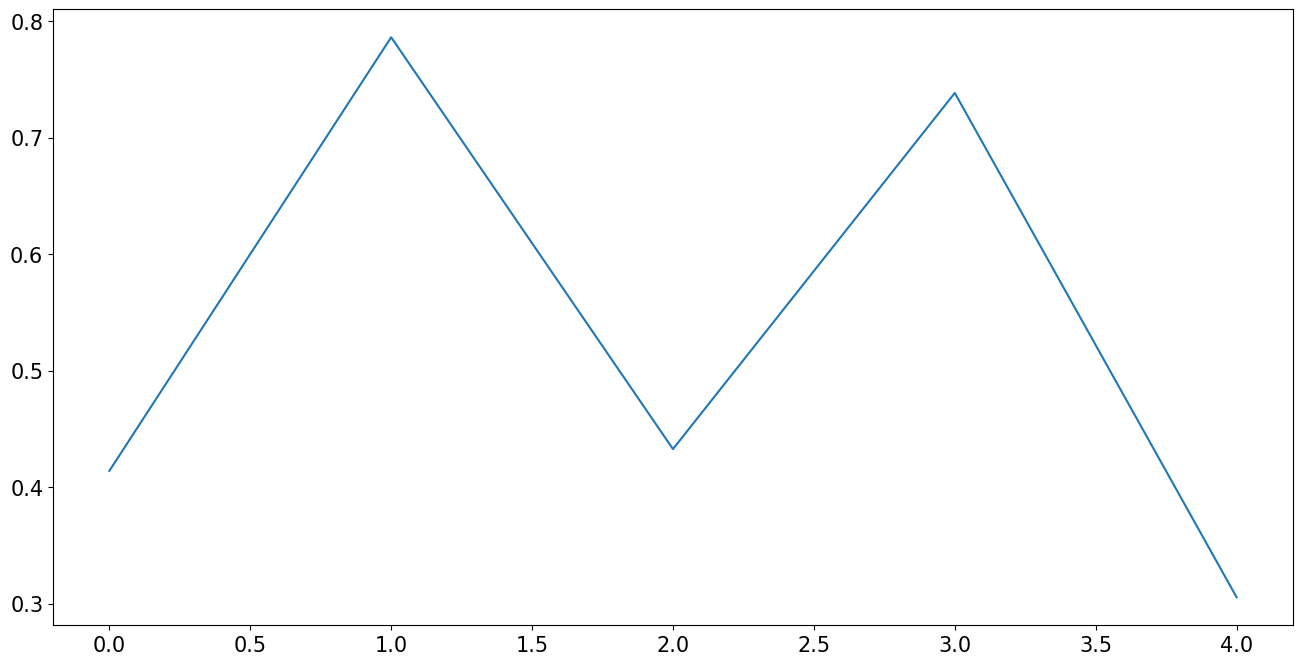

-0.7866869247891111

In [32]:
x = np.random.rand(5)

plt.plot(x)
plt.show()

mod = UnobservedComponents(endog = x, level = 'llevel')
mod.loglike([0.1, 0])

In [30]:
#mod.fit()
help(mod.loglike)

Help on method loglike in module statsmodels.tsa.statespace.mlemodel:

loglike(params, *args, **kwargs) method of __main__.TVRegression instance
    Loglikelihood evaluation
    
    Parameters
    ----------
    params : array_like
        Array of parameters at which to evaluate the loglikelihood
        function.
    transformed : bool, optional
        Whether or not `params` is already transformed. Default is True.
    **kwargs
        Additional keyword arguments to pass to the Kalman filter. See
        `KalmanFilter.filter` for more details.
    
    See Also
    --------
    update : modifies the internal state of the state space model to
             reflect new params
    
    Notes
    -----
    [1]_ recommend maximizing the average likelihood to avoid scale issues;
    this is done automatically by the base Model fit method.
    
    References
    ----------
    .. [1] Koopman, Siem Jan, Neil Shephard, and Jurgen A. Doornik. 1999.
       Statistical Algorithms for Models 

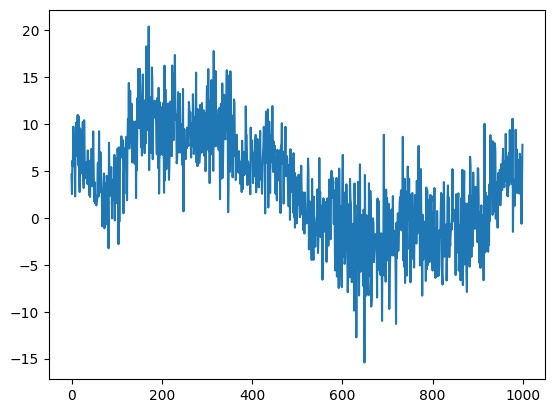

In [21]:
def gen_data_for_model1():
    nobs = 1000

    rs = np.random.RandomState(seed=93572)

    d = 5
    var_y = 5
    var_coeff_x = 0.01
    var_coeff_w = 0.5

    x_t = rs.uniform(size=nobs)
    w_t = rs.uniform(size=nobs)
    eps = rs.normal(scale=var_y ** 0.5, size=nobs)

    beta_x = np.cumsum(rs.normal(size=nobs, scale=var_coeff_x ** 0.5))
    beta_w = np.cumsum(rs.normal(size=nobs, scale=var_coeff_w ** 0.5))

    y_t = d + beta_x * x_t + beta_w * w_t + eps
    return y_t, x_t, w_t, beta_x, beta_w


y_t, x_t, w_t, beta_x, beta_w = gen_data_for_model1()
_ = plt.plot(y_t)


In [24]:
class TVRegression(sm.tsa.statespace.MLEModel):
    def __init__(self, y_t, x_t, w_t):
        exog = np.c_[x_t, w_t]  # shaped nobs x 2

        super(TVRegression, self).__init__(
            endog=y_t, exog=exog, k_states=2, initialization="diffuse"
        )

        # Since the design matrix is time-varying, it must be
        # shaped k_endog x k_states x nobs
        # Notice that exog.T is shaped k_states x nobs, so we
        # just need to add a new first axis with shape 1
        self.ssm["design"] = exog.T[np.newaxis, :, :]  # shaped 1 x 2 x nobs
        self.ssm["selection"] = np.eye(self.k_states)
        self.ssm["transition"] = np.eye(self.k_states)

        # Which parameters need to be positive?
        self.positive_parameters = slice(1, 4)

    @property
    def param_names(self):
        return ["intercept", "var.e", "var.x.coeff", "var.w.coeff"]

    @property
    def start_params(self):
        """
        Defines the starting values for the parameters
        The linear regression gives us reasonable starting values for the constant
        d and the variance of the epsilon error
        """
        exog = sm.add_constant(self.exog)
        res = sm.OLS(self.endog, exog).fit()
        params = np.r_[res.params[0], res.scale, 0.001, 0.001]
        return params

    def transform_params(self, unconstrained):
        """
        We constraint the last three parameters
        ('var.e', 'var.x.coeff', 'var.w.coeff') to be positive,
        because they are variances
        """
        constrained = unconstrained.copy()
        constrained[self.positive_parameters] = (
            constrained[self.positive_parameters] ** 2
        )
        return constrained

    def untransform_params(self, constrained):
        """
        Need to unstransform all the parameters you transformed
        in the `transform_params` function
        """
        unconstrained = constrained.copy()
        unconstrained[self.positive_parameters] = (
            unconstrained[self.positive_parameters] ** 0.5
        )
        return unconstrained

    def update(self, params, **kwargs):
        params = super(TVRegression, self).update(params, **kwargs)

        self["obs_intercept", 0, 0] = params[0]
        self["obs_cov", 0, 0] = params[1]
        self["state_cov"] = np.diag(params[2:4])


In [26]:
mod = TVRegression(y_t, x_t, w_t)
res = mod.fit()

print(res.summary())


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.95797D+00    |proj g|=  3.07855D+00

At iterate    5    f=  2.35192D+00    |proj g|=  1.20032D-01

At iterate   10    f=  2.33741D+00    |proj g|=  9.04232D-03

At iterate   15    f=  2.33685D+00    |proj g|=  7.50086D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     16     25      1     0     0   3.104D-06   2.337D+00
  F =   2.3368462404860639     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


 This problem is unconstrained.


                           Statespace Model Results                           
Dep. Variable:                      y   No. Observations:                 1000
Model:                   TVRegression   Log Likelihood               -2336.846
Date:                Fri, 10 Jan 2025   AIC                           4685.692
Time:                        12:11:57   BIC                           4715.139
Sample:                             0   HQIC                          4696.884
                               - 1000                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       5.0548      0.202     25.050      0.000       4.659       5.450
var.e           5.1240      0.249     20.571      0.000       4.636       5.612
var.x.coeff     0.0468      0.022      2.097    

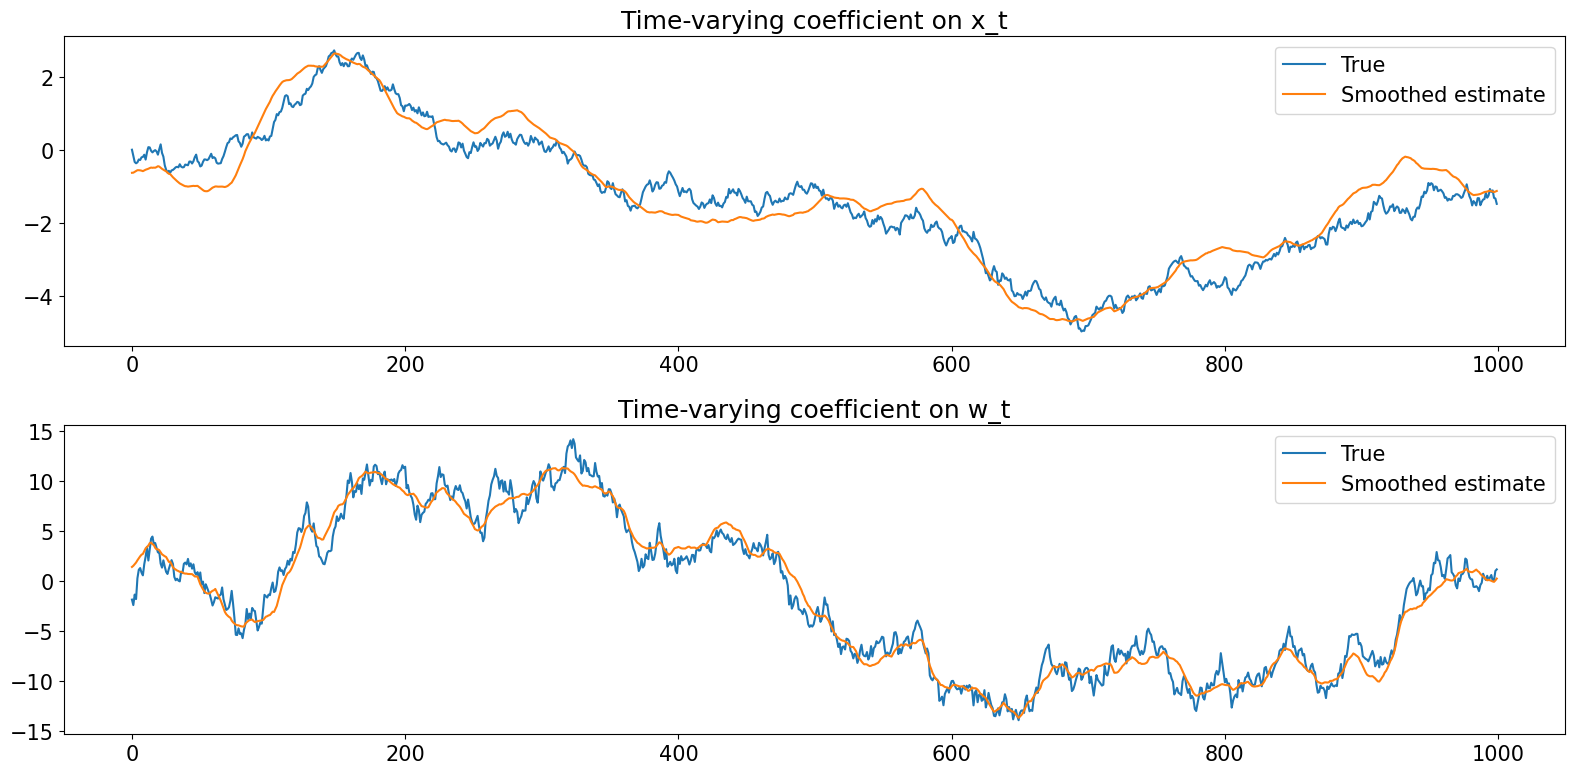

In [27]:
fig, axes = plt.subplots(2, figsize=(16, 8))

ss = pd.DataFrame(res.smoothed_state.T, columns=["x", "w"])

axes[0].plot(beta_x, label="True")
axes[0].plot(ss["x"], label="Smoothed estimate")
axes[0].set(title="Time-varying coefficient on x_t")
axes[0].legend()

axes[1].plot(beta_w, label="True")
axes[1].plot(ss["w"], label="Smoothed estimate")
axes[1].set(title="Time-varying coefficient on w_t")
axes[1].legend()

fig.tight_layout();
